In [1]:
!pip install -q torch_snippets # instala biblioteca
from torch_snippets import * # importa funções
import torch # importa biblioteca do pytorch
import torch.nn as nn # importa redes neurais
import torch.nn.functional as F # importa funções de ativação
import torch.optim as optim # importa algoritmos de otimização
from torchvision import datasets, transforms # importa ferramentas para visão computacional
from torchvision.utils import make_grid # importa função para criar grades de imagens
device = 'cuda' if torch.cuda.is_available() else 'cpu' # define uso de gpu ou cpu

train_dataset = datasets.MNIST(root='MNIST/', train=True, transform=transforms.ToTensor(), download=True) # baixa e carrega treino
test_dataset = datasets.MNIST(root='MNIST/', train=False, transform=transforms.ToTensor(), download=True) # baixa ecarrega teste

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True) # cria carregador de treino
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False) # cria carregador de teste

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.2 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.14MB/s]


In [2]:
train_dataset[0][0]

tensor[1, 28, 28] n=784 (3.06 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.138 σ=0.313

In [8]:
import torch # biblioteca principal
import torch.nn as nn # módulos de rede neural
import torch.nn.functional as F # funções de ativação
from torch.autograd import Variable

class VAE(nn.Module): # define classe
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder network
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc21 = nn.Linear(256, 20)
        self.fc22 = nn.Linear(256, 20)

        # Decoder network
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()).to(device))
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar

In [5]:
def train_batch(data,model,optimizer,loss_function): # função de treino
    model.train()
    data = data.to(device) # move entrada
    optimizer.zero_grad() # zera gradientes acumulados
    recon_batch, mean, log_var = model(data) # passa pelo vae
    loss,mse,kld = loss_function(recon_batch, data, mean, log_var) # calcula perdas
    loss.backward() # calcula gradientes
    optimizer.step() # atualiza os pesos
    return loss, mse, kld, log_var.mean(), mean.mean() # retorna metricas

@torch.no_grad() # desativa gradientes
def validate_batch(data,model,loss_function): # função de validação
    model.eval()
    data = data.to(device) # move entrada
    recon,mean,log_var = model(data) # gera reconstrução
    loss, mse, kld = loss_function(recon,data,mean,log_var) # calcula perdas
    return loss, mse, kld, log_var.mean(), mean.mean() # retorna

In [6]:
def loss_function(recon_x, x, mean, log_var): # define a perda do vae
    RECON = F.mse_loss(recon_x, x, reduction='sum') # erro de reconstrução
    KLD = -0.5 * torch.sum(1+log_var-mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD # retorna perda

EPOCH: 1.000  train_recon: 2502.563  train_log_var: -0.483  train_kld: 330.588  train_mean: 0.002  train_loss: 2833.151  val_recon: 1351.611  val_log_var: -0.856  val_kld: 562.211  val_mean: -0.001  val_loss: 1913.823  (72.64s - 653.72s remaining)


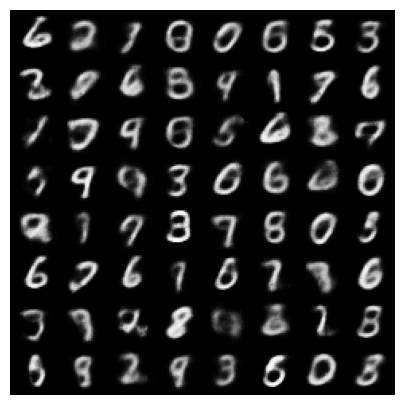

EPOCH: 2.000  train_recon: 1469.392  train_log_var: -0.928  train_kld: 599.910  train_mean: 0.003  train_loss: 2069.302  val_recon: 1135.988  val_log_var: -0.988  val_kld: 637.800  val_mean: -0.009  val_loss: 1773.788  (152.45s - 609.79s remaining)


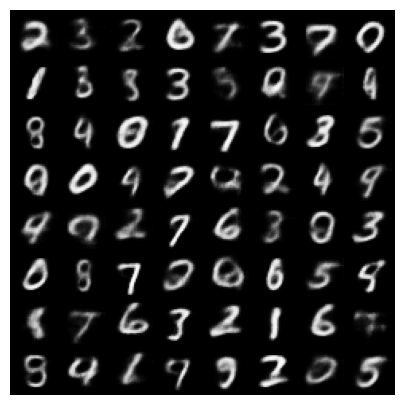

EPOCH: 3.000  train_recon: 1333.302  train_log_var: -0.995  train_kld: 638.700  train_mean: 0.002  train_loss: 1972.001  val_recon: 1014.389  val_log_var: -0.981  val_kld: 622.515  val_mean: -0.009  val_loss: 1636.904  (234.31s - 546.73s remaining)


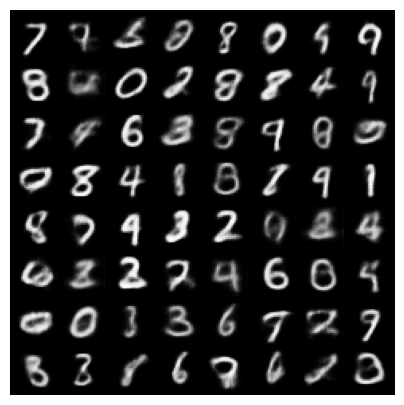

EPOCH: 4.000  train_recon: 1259.469  train_log_var: -1.035  train_kld: 662.918  train_mean: 0.002  train_loss: 1922.387  val_recon: 962.211  val_log_var: -1.071  val_kld: 691.542  val_mean: 0.008  val_loss: 1653.753  (315.18s - 472.78s remaining)


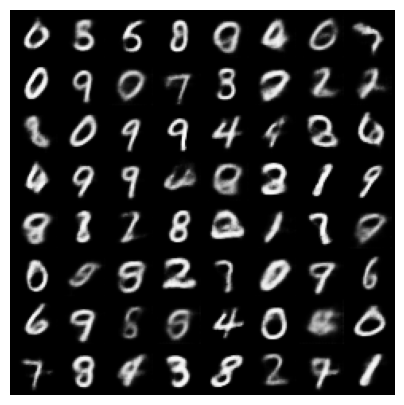

EPOCH: 5.000  train_recon: 1208.677  train_log_var: -1.064  train_kld: 681.269  train_mean: 0.002  train_loss: 1889.946  val_recon: 899.709  val_log_var: -1.083  val_kld: 693.066  val_mean: 0.005  val_loss: 1592.775  (395.76s - 395.76s remaining)


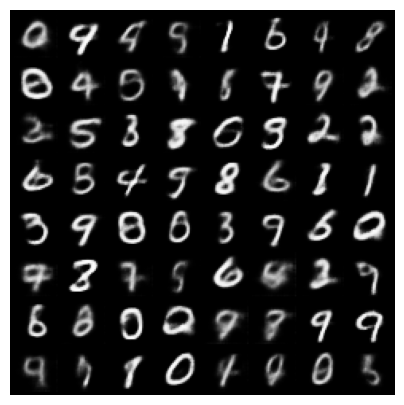

EPOCH: 6.000  train_recon: 1169.002  train_log_var: -1.086  train_kld: 694.513  train_mean: 0.002  train_loss: 1863.515  val_recon: 860.498  val_log_var: -1.118  val_kld: 715.859  val_mean: -0.008  val_loss: 1576.356  (476.08s - 317.38s remaining)


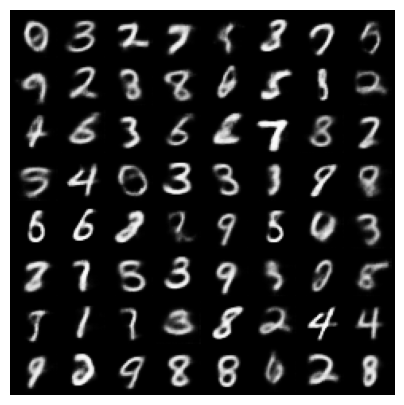

EPOCH: 7.000  train_recon: 1136.621  train_log_var: -1.106  train_kld: 707.542  train_mean: 0.001  train_loss: 1844.163  val_recon: 837.619  val_log_var: -1.091  val_kld: 686.559  val_mean: -0.012  val_loss: 1524.178  (557.37s - 238.87s remaining)


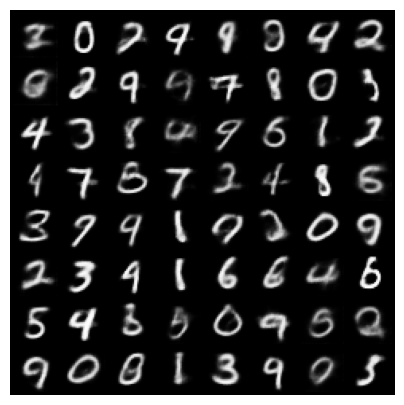

EPOCH: 8.000  train_recon: 1110.818  train_log_var: -1.120  train_kld: 716.434  train_mean: 0.001  train_loss: 1827.253  val_recon: 830.249  val_log_var: -1.136  val_kld: 717.480  val_mean: -0.009  val_loss: 1547.730  (637.73s - 159.43s remaining)


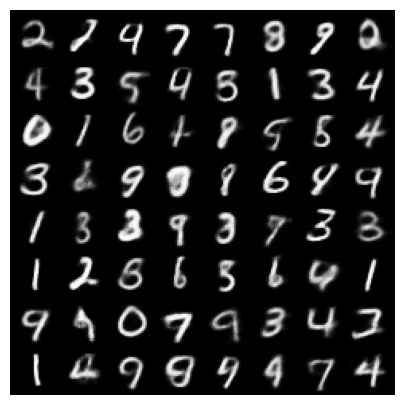

EPOCH: 9.000  train_recon: 1093.340  train_log_var: -1.130  train_kld: 722.535  train_mean: 0.001  train_loss: 1815.875  val_recon: 803.376  val_log_var: -1.182  val_kld: 748.404  val_mean: -0.009  val_loss: 1551.780  (720.39s - 80.04s remaining)


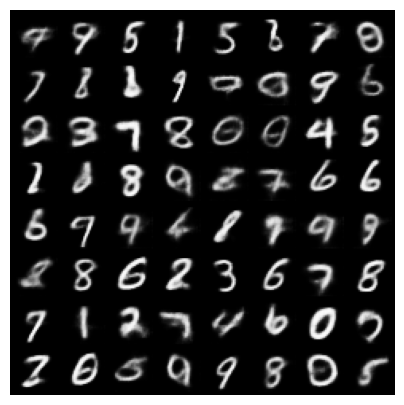

EPOCH: 10.000  train_recon: 1078.748  train_log_var: -1.136  train_kld: 726.587  train_mean: 0.001  train_loss: 1805.335  val_recon: 801.905  val_log_var: -1.114  val_kld: 698.922  val_mean: -0.017  val_loss: 1500.827  (802.47s - 0.00s remaining)


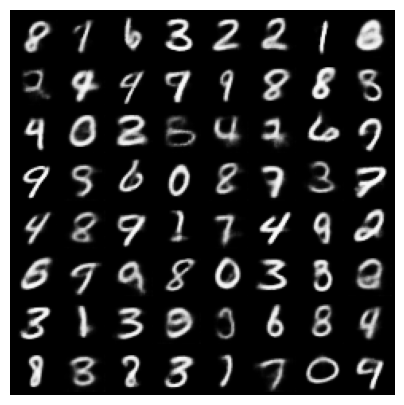

In [9]:
n_epochs = 10 # define número de épocas
log = Report(n_epochs) # inicializa objeto de log/relatório
vae = VAE().to(device) # cria o modelo VAE e move para gpu/cpu
optimizer = optim.AdamW(vae.parameters(), lr=1e-3) # define otimizador com taxa de aprendizado

for epoch in range(n_epochs): # loop de épocas
    N = len(train_loader) # total de lotes de treino
    for batch_idx, (data, _) in enumerate(train_loader): # loop de treino
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function) # executa treino do lote
        pos = epoch + (1+batch_idx)/N # calcula posição decimal da época
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r') # registra métricas de treino

    N = len(test_loader) # total de lotes de teste
    for batch_idx, (data, _) in enumerate(test_loader): # loop de validação
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function) # executa validação do lote
        pos = epoch + (1+batch_idx)/N # calcula posição no log
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r') # registra métricas de validação

    log.report_avgs(epoch+1) # exibe médias ao fim da época
    with torch.no_grad(): # desativa gradientes para geração
        z = torch.randn(64, 20).to(device) # gera 64 vetores latentes aleatórios
        sample = vae.decode(z).to(device) # decodifica vetores em imagens
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0) # cria grade de imagens para exibição
        show(images) # exibe as imagens geradas pelo VAE